In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Load Dataset
df = pd.read_csv('video_games_sales.csv')

# Remove missing years
df = df.dropna(subset=['Year'])

# Convert Year to integer
df['Year'] = df['Year'].astype(int)

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 1.Which gaming platforms generated the highest global sales?

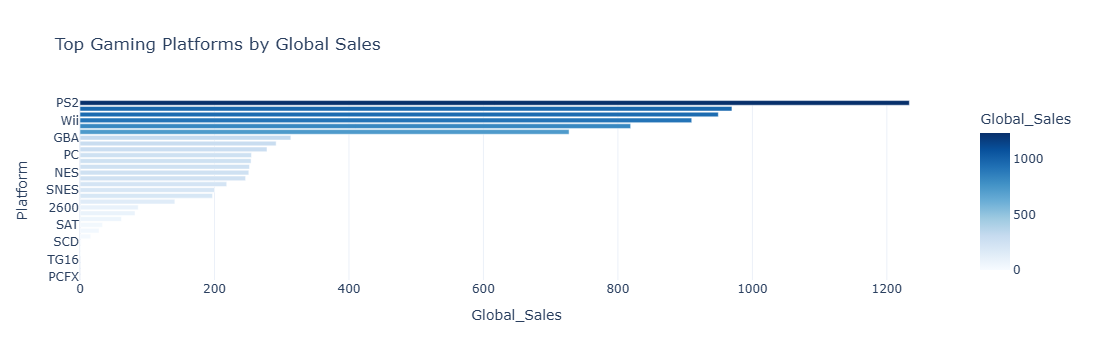

In [2]:
platform_sales = (
    df.groupby("Platform")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

fig = px.bar(
    platform_sales,
    x="Global_Sales",
    y="Platform",
    orientation="h",
    title="Top Gaming Platforms by Global Sales",
    color="Global_Sales",
    color_continuous_scale="Blues"
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

**Insight** :Global video game sales are concentrated among a relatively small number of platforms. The leading platforms accumulated substantially higher lifetime sales than the rest, indicating that platform popularity and installed user base play an important role in determining total game sales. The long tail of platforms contributes comparatively less to the overall market.

## 2.How has global video game sales changed over time?

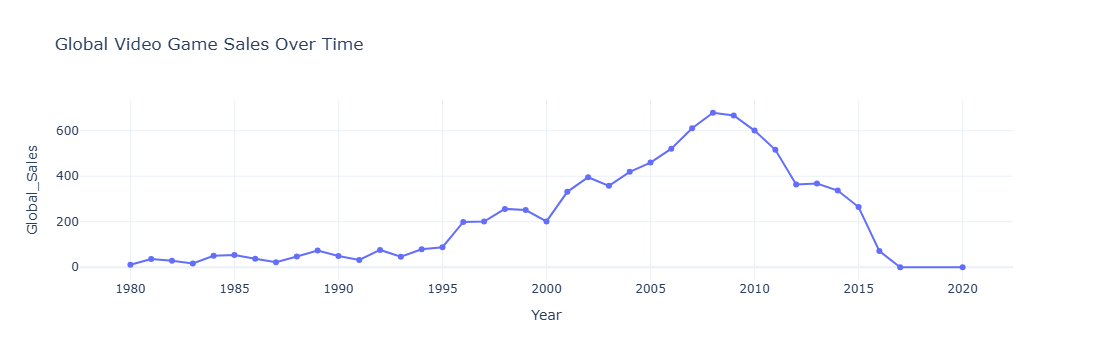

In [3]:
year_sales = (
    df.groupby("Year")["Global_Sales"]
      .sum()
      .reset_index()
)

fig = px.line(
    year_sales,
    x="Year",
    y="Global_Sales",
    markers=True,
    title="Global Video Game Sales Over Time"
)

fig.update_layout(template="plotly_white")

fig.show()

**Insight** : Global video game sales vary considerably across years rather than increasing continuously. The trend shows periods of strong market growth followed by declines, reflecting changes in gaming generations, consumer demand, and the popularity of major releases.

## 3.Which genres perform best across North America, Europe, and Japan?

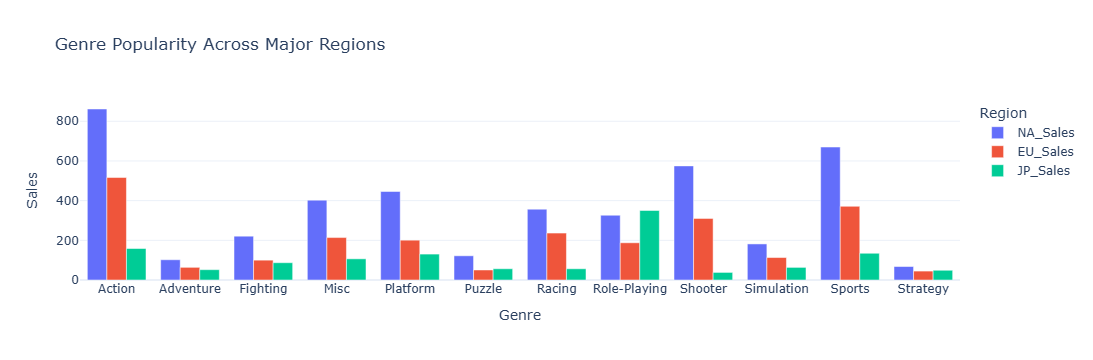

In [4]:
genre_region = (
    df.groupby("Genre")[["NA_Sales","EU_Sales","JP_Sales"]]
      .sum()
      .reset_index()
)

genre_region = genre_region.melt(
    id_vars="Genre",
    var_name="Region",
    value_name="Sales"
)

fig = px.bar(
    genre_region,
    x="Genre",
    y="Sales",
    color="Region",
    barmode="group",
    title="Genre Popularity Across Major Regions"
)

fig.update_layout(template="plotly_white")

fig.show()

**Insight** : Genre preferences differ across regions. While some genres perform strongly across multiple markets, the relative contribution of genres varies between North America, Europe, and Japan. This indicates that regional gaming markets have different consumer preferences.

## 4.Which publishers dominate the global video game market?

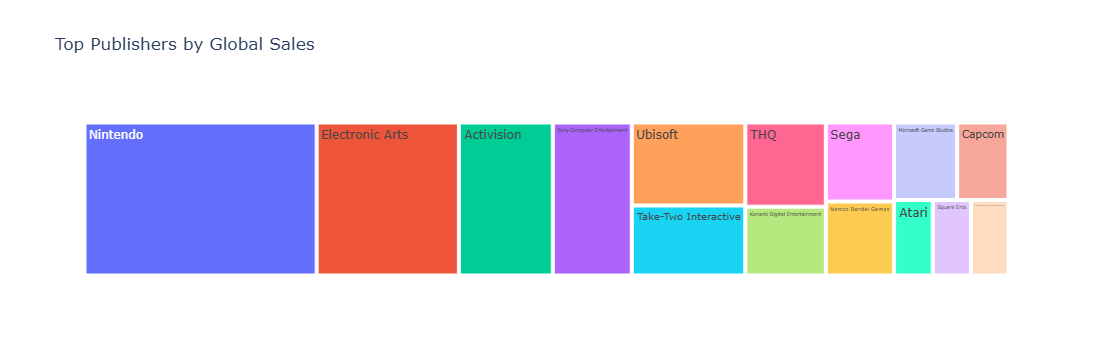

In [5]:
publisher_sales = (
    df.groupby("Publisher")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
      .reset_index()
)

fig = px.treemap(
    publisher_sales,
    path=["Publisher"],
    values="Global_Sales",
    title="Top Publishers by Global Sales"
)

fig.show()

**Insight** : The publisher analysis shows a highly competitive but concentrated market, with a relatively small group of publishers accounting for a large share of cumulative global sales. The largest publishers have a much greater sales footprint than smaller publishers.

## 5.Which platform is strongest for each game genre?

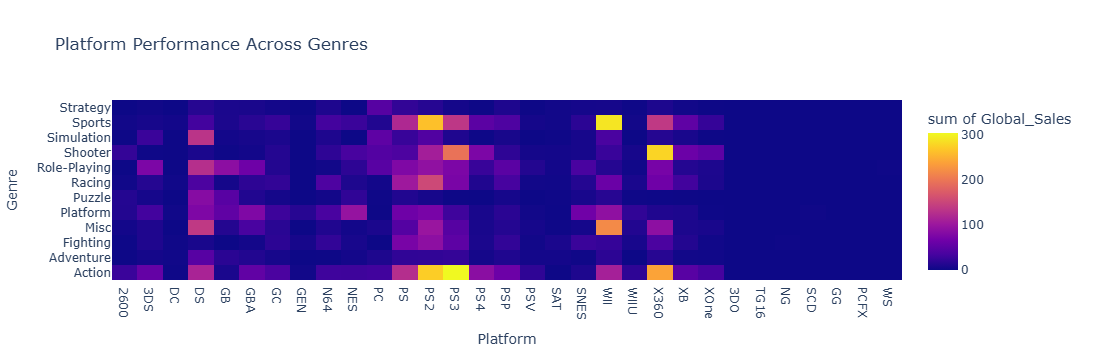

In [6]:
heatmap = (
    df.groupby(["Genre","Platform"])["Global_Sales"]
      .sum()
      .reset_index()
)

fig = px.density_heatmap(
    heatmap,
    x="Platform",
    y="Genre",
    z="Global_Sales",
    title="Platform Performance Across Genres"
)

fig.update_layout(template="plotly_white")

fig.show()

**Insight** : Platform performance is not uniform across genres. Different platforms show stronger sales for particular genres, indicating that platform audiences have different gaming preferences. Some platform–genre combinations stand out as particularly strong.

## 6.Which regions contribute the most to global sales?

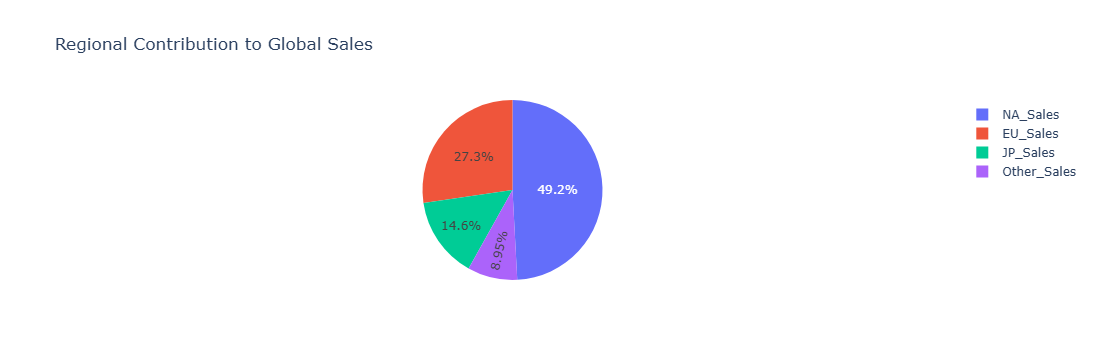

In [7]:
sales = df[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()

sales_df = pd.DataFrame({
    "Region":sales.index,
    "Sales":sales.values
})

fig = px.pie(
    sales_df,
    names="Region",
    values="Sales",
    title="Regional Contribution to Global Sales"
)

fig.show()

**Insight** : The regional sales analysis shows that global video game revenue is unevenly distributed geographically. North America and Europe represent major contributors to overall sales, while Japan and other markets contribute different proportions.

## 7.How have different game genres evolved over time?

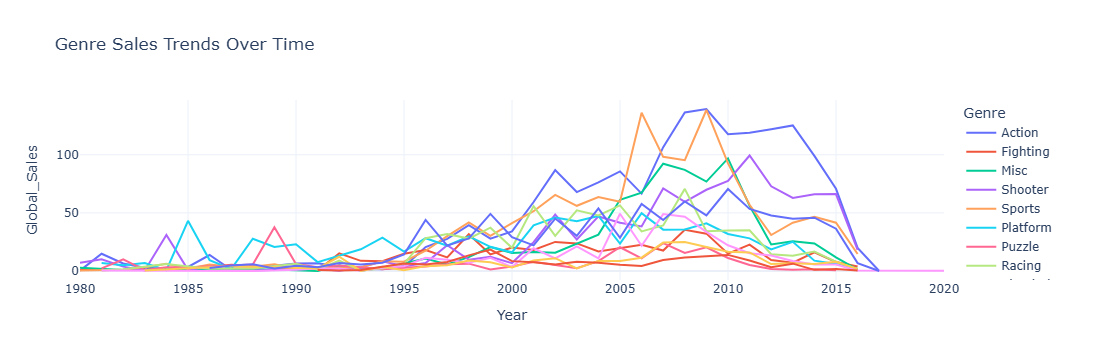

In [8]:
genre_year = (
    df.groupby(["Year","Genre"])["Global_Sales"]
      .sum()
      .reset_index()
)

fig = px.line(
    genre_year,
    x="Year",
    y="Global_Sales",
    color="Genre",
    title="Genre Sales Trends Over Time"
)

fig.update_layout(template="plotly_white")

fig.show()

**Insight** :Genre popularity changes across different periods. Some genres experience strong growth during particular periods, while others decline or remain relatively stable. This suggests that consumer preferences evolve alongside gaming technology and platform generations.Insight 

## 8.Which publishers specialize in particular genres?

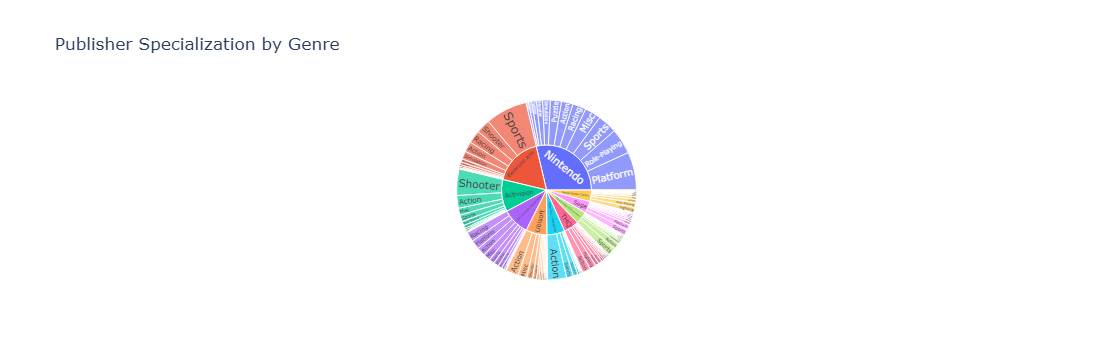

In [9]:
pub_genre = (
    df.groupby(["Publisher","Genre"])["Global_Sales"]
      .sum()
      .reset_index()
)

top_publishers = (
    pub_genre.groupby("Publisher")["Global_Sales"]
      .sum()
      .nlargest(10)
      .index
)

pub_genre = pub_genre[
    pub_genre["Publisher"].isin(top_publishers)
]

fig = px.sunburst(
    pub_genre,
    path=["Publisher","Genre"],
    values="Global_Sales",
    title="Publisher Specialization by Genre"
)

fig.show()

**Insight**:The sunburst shows that major publishers do not necessarily have identical genre portfolios. Some publishers generate sales across many genres, while others have stronger concentration in particular genres.

## 9.Which platforms have the longest lifespan and highest cumulative sales?

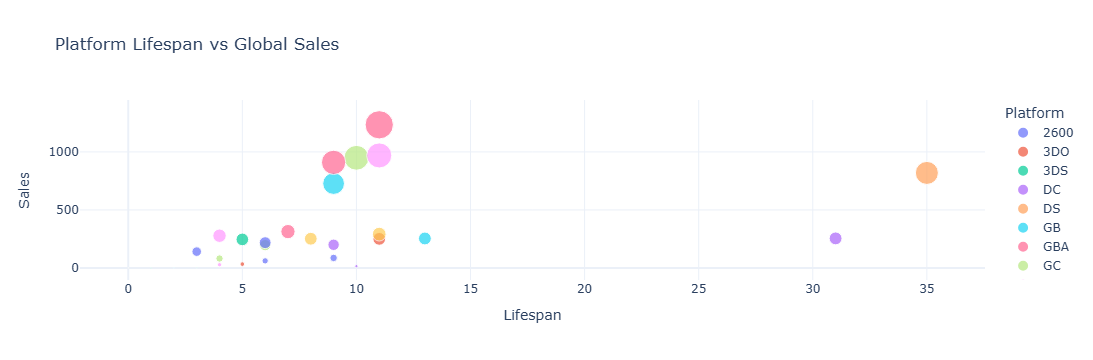

In [10]:
life = (
    df.groupby("Platform")
      .agg(
          First=("Year","min"),
          Last=("Year","max"),
          Sales=("Global_Sales","sum")
      )
      .reset_index()
)

life["Lifespan"] = life["Last"] - life["First"]

fig = px.scatter(
    life,
    x="Lifespan",
    y="Sales",
    size="Sales",
    color="Platform",
    hover_name="Platform",
    title="Platform Lifespan vs Global Sales"
)

fig.update_layout(template="plotly_white")

fig.show()

**Insight**: Platform longevity and sales are related, but a longer lifespan does not automatically guarantee the highest cumulative sales. Some platforms remain active for many years and accumulate substantial sales, while others achieve strong sales within a shorter lifecycle.

## 10.Which games are the biggest global blockbusters?

In [ ]:
top_games = (
    df.sort_values("Global_Sales",ascending=False)
      .head(20)
)

fig = px.bar(
    top_games,
    x="Global_Sales",
    y="Name",
    orientation="h",
    color="Genre",
    title="Top 20 Best-Selling Video Games"
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

**Insight** : Global sales are heavily concentrated among a relatively small number of blockbuster titles. The top-selling games substantially outperform typical games in cumulative global sales, demonstrating the importance of major franchises and highly successful releases in the video game market.

## Conclusion

The analysis of global video game sales reveals a highly competitive and dynamic industry shaped by platform popularity, genre preferences, publisher strategies, regional demand, and changing consumer trends over time. Global sales are concentrated among a relatively small number of major platforms, publishers, and blockbuster titles, while many other products and platforms contribute smaller shares of the market.

The analysis also shows that gaming preferences vary across regions and genres. Different platforms perform strongly for different genres, and publishers follow different portfolio strategies, with some maintaining diversified genre offerings while others show greater specialization. In addition, platform longevity does not necessarily guarantee higher cumulative sales, indicating that commercial success depends on more than simply remaining in the market for a long period.

Overall, the findings demonstrate that the video game market is driven by a combination of **platform reach, genre popularity, regional preferences, publisher strength, product longevity, and blockbuster performance**. These patterns provide useful insights into how gaming trends have evolved and why certain platforms, publishers, and games have achieved exceptional global success.
